## Imports

### Libs

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


2025-06-03 19:21:19.285514: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-03 19:21:19.319079: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 19:21:19.494152: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 19:21:19.655372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748971279.834681   42154 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748971279.87

### SRC

In [ ]:
from mlp_basic_models import create_basic_mlp, train_basic_mlp
from mlp_final_training import evaluate_mlp_model


## Loading Data

(60000, 28, 28)


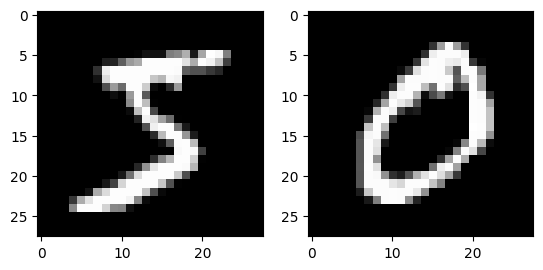

In [ ]:
# Let's load the famous MNIST dataset


from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.
X_test = X_test / 255.

print(X_train.shape)
plt.subplot(1,2,1)
plt.imshow(X_train[0], cmap="gray");
plt.subplot(1,2,2)
plt.imshow(X_train[1], cmap="gray");

## Data Processing

In [ ]:
# Reshape the X to explicitly add a single "color" channel
X_train = X_train.reshape(len(X_train), 28, 28, 1)
X_test = X_test.reshape(len(X_test), 28, 28, 1)
X_train.shape

(60000, 28, 28, 1)

In [ ]:
# One Hot Encode our Target for TensorFlow processing
y_cat_train = to_categorical(y_train, num_classes=10)
y_cat_test = to_categorical(y_test, num_classes=10)
y_cat_train.shape

(60000, 10)

## MLP Models

### Basic MLP model

In [ ]:
basic_model = create_basic_mlp()
basic_history = train_basic_mlp(basic_model, X_train, y_cat_train, epochs=30)
basic_eval = evaluate_mlp_model(basic_model, X_test, y_cat_test)

### Advanced MLP Model

In [ ]:
from mlp_basic_models import create_advanced_mlp, compile_advanced_mlp, get_default_advanced_config
from tensorflow.keras.callbacks import EarlyStopping

config = get_default_advanced_config()
advanced_model = create_advanced_mlp(config)
advanced_model = compile_advanced_mlp(advanced_model, config)

# Training avec callbacks
callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
history = advanced_model.fit(X_train, y_cat_train, validation_split=0.2,
                            epochs=50, callbacks=callbacks)

### Grid Search

In [ ]:
from mlp_grid_search import mlp_grid_search, analyze_mlp_results

# Quick search (8 combinations, ~10-15 minutes)
results = mlp_grid_search(X_train, y_cat_train, search_type='quick')
best_config, analysis = analyze_mlp_results(results)

# Ou medium search (20 combinations, ~30-45 minutes)
# results = mlp_grid_search(X_train, y_cat_train, search_type='medium')

### Final Model

In [ ]:
from mlp_final_training import train_final_mlp, evaluate_mlp_model

final_model, final_history = train_final_mlp(
    best_config,  # Du grid search
    X_train, y_cat_train,
    epochs=100,
    save_path='final_mlp_model.h5'
)

final_eval = evaluate_mlp_model(final_model, X_test, y_cat_test)